# 4 — Spectral Gap as an Early Warning Indicator for Market Stress

**Goal:** Test whether the rolling spectral gap Δλ of ordinal transition matrices provides
a statistically significant early warning signal **before** major cryptocurrency market stress events.

**Analysis pipeline:**
1. Event study — pre/post Δλ for four crisis events (Bear start Nov-2021, LUNA May-2022, FTX Nov-2022, Correction Apr-2025)
2. Granger causality — lagged Δλ → next-period realized volatility
3. Threshold-based warning — precision / lead time when Δλ drops > 1 SD below rolling mean
4. Cross-sectional comparison — which coins provide the earliest warning?
5. Figures & tables for manuscript Section 4.7

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
DATA_DIR = Path('data')

# ── reproducibility ──
np.random.seed(42)

# ── style ──
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

COINS = ['BTC', 'ETH', 'BNB', 'SOL', 'XRP', 'ADA', 'DOGE', 'LTC']
COLORS = plt.cm.tab10(np.linspace(0, 0.9, 8))
COIN_COLOR = dict(zip(COINS, COLORS))

print('Imports OK')

Imports OK


In [2]:
# ── Load rolling network metrics ──
metrics = pd.read_csv(DATA_DIR / 'network_metrics_rolling.csv')
metrics['date'] = pd.to_datetime(metrics['date'], utc=True)
metrics = metrics.sort_values(['coin', 'date']).reset_index(drop=True)

# ── Load daily log-returns ──
returns = pd.read_csv(DATA_DIR / 'preprocessed_log_returns.csv',
                      index_col=0, parse_dates=True)
returns.index = pd.to_datetime(returns.index, utc=True)
returns = returns.sort_index()

print('Metrics shape :', metrics.shape)
print('Returns shape :', returns.shape)
print('Metrics date range:', metrics['date'].min().date(), '→', metrics['date'].max().date())
print('Returns date range:', returns.index.min().date(), '→', returns.index.max().date())
print('\nMetrics per coin:', metrics.groupby('coin').size().to_dict())

Metrics shape : (544, 8)
Returns shape : (2210, 8)
Metrics date range: 2020-10-07 → 2026-04-09
Returns date range: 2020-04-11 → 2026-04-29

Metrics per coin: {'ADA': 68, 'BNB': 68, 'BTC': 68, 'DOGE': 68, 'ETH': 68, 'LTC': 68, 'SOL': 68, 'XRP': 68}


In [3]:
# ══════════════════════════════════════════════════════════════════
# 1.  BASELINE STATISTICS  (calm-market reference)
# ══════════════════════════════════════════════════════════════════
# Calm period = Recovery 2023 (Jan 2023 – Dec 2023)
# Used as the reference distribution for z-scoring

calm_start = pd.Timestamp('2023-01-01', tz='UTC')
calm_end   = pd.Timestamp('2023-12-31', tz='UTC')

calm = metrics[(metrics['date'] >= calm_start) & (metrics['date'] <= calm_end)]

baseline = calm.groupby('coin')['spectral_gap'].agg(
    mu='mean', sigma='std').reset_index()

# Also compute full-sample baseline
full_baseline = metrics.groupby('coin')['spectral_gap'].agg(
    mu_full='mean', sigma_full='std').reset_index()

baseline = baseline.merge(full_baseline, on='coin')
print('Calm-period baseline (2023):')
print(baseline.set_index('coin').round(4).to_string())

Calm-period baseline (2023):
          mu   sigma  mu_full  sigma_full
coin                                     
ADA   0.4859  0.0602   0.5134      0.0765
BNB   0.4890  0.0291   0.4871      0.0591
BTC   0.5278  0.0310   0.5247      0.0708
DOGE  0.5152  0.0317   0.5092      0.0703
ETH   0.4293  0.0159   0.4739      0.0517
LTC   0.5146  0.0388   0.4805      0.0504
SOL   0.5432  0.0959   0.5105      0.0760
XRP   0.4956  0.0384   0.5078      0.0479


In [4]:
# ══════════════════════════════════════════════════════════════════
# 2.  EVENT DEFINITIONS
# ══════════════════════════════════════════════════════════════════

EVENTS = {
    'Bear Start\n(Nov 2021)':  pd.Timestamp('2021-11-08', tz='UTC'),
    'LUNA Collapse\n(May 2022)': pd.Timestamp('2022-05-09', tz='UTC'),
    'FTX Bankruptcy\n(Nov 2022)': pd.Timestamp('2022-11-11', tz='UTC'),
    'Correction\n(Apr 2025)':   pd.Timestamp('2025-04-02', tz='UTC'),
}

EVENT_KEYS = list(EVENTS.keys())
print('Events defined:', [k.replace('\n', ' ') for k in EVENT_KEYS])

Events defined: ['Bear Start (Nov 2021)', 'LUNA Collapse (May 2022)', 'FTX Bankruptcy (Nov 2022)', 'Correction (Apr 2025)']


In [5]:
# ══════════════════════════════════════════════════════════════════
# 3.  EVENT STUDY — spectral gap cross-sectional mean around each event
# ══════════════════════════════════════════════════════════════════

WINDOW_DAYS = 100  # ± 100 days around event

event_study = {}   # {event_name: DataFrame(date, coin, spectral_gap, days_to_event)}

for event_name, event_date in EVENTS.items():
    lo = event_date - pd.Timedelta(days=WINDOW_DAYS)
    hi = event_date + pd.Timedelta(days=WINDOW_DAYS)
    w  = metrics[(metrics['date'] >= lo) & (metrics['date'] <= hi)].copy()
    w['days_to_event'] = (w['date'] - event_date).dt.days
    
    # Merge baseline for z-scoring
    w = w.merge(baseline[['coin', 'mu', 'sigma']], on='coin')
    w['sg_z'] = (w['spectral_gap'] - w['mu']) / w['sigma']  # z-score vs calm-2023 baseline
    event_study[event_name] = w

# Build summary table: mean spectral gap per relative time-bin
# Bins: [-100,-60), [-60,-30), [-30,0), [0,+30), [+30,+60), [+60,+100]
BINS  = [-100, -60, -30, 0, 30, 60, 100]
BLABELS = ['t−100→−60', 't−60→−30', 't−30→0',
           't+0→+30',  't+30→+60', 't+60→+100']

summary_rows = []
for event_name, event_date in EVENTS.items():
    w = event_study[event_name]
    w['bin'] = pd.cut(w['days_to_event'], bins=BINS, labels=BLABELS, right=False)
    for b in BLABELS:
        sub = w[w['bin'] == b]
        if len(sub) == 0:
            continue
        summary_rows.append({
            'event':    event_name.replace('\n', ' '),
            'bin':      b,
            'sg_mean':  sub['spectral_gap'].mean(),
            'sg_std':   sub['spectral_gap'].std(),
            'sg_z_mean': sub['sg_z'].mean(),
            'n_obs':    len(sub),
        })

summary_df = pd.DataFrame(summary_rows)
print('Event study summary:')
print(summary_df.to_string(index=False, float_format='{:.4f}'.format))

Event study summary:
                    event       bin  sg_mean  sg_std  sg_z_mean  n_obs
    Bear Start (Nov 2021) t−100→−60   0.4651  0.0479    -0.6829     16
    Bear Start (Nov 2021)  t−60→−30   0.4409  0.0316    -1.4084      8
    Bear Start (Nov 2021)    t−30→0   0.4508  0.0236    -1.0872      8
    Bear Start (Nov 2021)   t+0→+30   0.4527  0.0205    -1.1216      8
    Bear Start (Nov 2021)  t+30→+60   0.4735  0.0286    -0.3208      8
    Bear Start (Nov 2021) t+60→+100   0.4738  0.0599     0.1123      8
 LUNA Collapse (May 2022) t−100→−60   0.4524  0.0588    -0.6656     16
 LUNA Collapse (May 2022)  t−60→−30   0.4533  0.0375    -0.6871      8
 LUNA Collapse (May 2022)    t−30→0   0.4534  0.0382    -0.7115      8
 LUNA Collapse (May 2022)   t+0→+30   0.4238  0.0349    -1.7578      8
 LUNA Collapse (May 2022)  t+30→+60   0.4793  0.0567    -0.2748      8
 LUNA Collapse (May 2022) t+60→+100   0.4612  0.0464    -0.9645      8
FTX Bankruptcy (Nov 2022) t−100→−60   0.5068  0.0460    

In [6]:
# ══════════════════════════════════════════════════════════════════
# 4.  PRE-EVENT DECLINE METRICS
# ══════════════════════════════════════════════════════════════════
# For each event, compute:
#   - Δλ in the last window before event (t-30 to t)
#   - Δλ in the calm reference before that (t-90 to t-30)
#   - Percentage decline = (pre - far_pre) / far_pre * 100

decline_rows = []
for event_name, event_date in EVENTS.items():
    w = event_study[event_name]
    
    far_pre = w[(w['days_to_event'] >= -90) & (w['days_to_event'] < -30)]
    near_pre = w[(w['days_to_event'] >= -30) & (w['days_to_event'] < 0)]
    post = w[(w['days_to_event'] >= 0) & (w['days_to_event'] <= 60)]
    
    if len(far_pre) == 0 or len(near_pre) == 0:
        continue

    # Cross-sectional means across 8 coins
    sg_far  = far_pre['spectral_gap'].mean()
    sg_near = near_pre['spectral_gap'].mean()
    sg_post = post['spectral_gap'].mean() if len(post) > 0 else np.nan
    pct_decline = (sg_near - sg_far) / sg_far * 100
    z_near = near_pre['sg_z'].mean()
    z_far  = far_pre['sg_z'].mean()

    # Per-coin pre-event decline
    for coin in COINS:
        fp = far_pre[far_pre['coin'] == coin]['spectral_gap'].mean()
        np_ = near_pre[near_pre['coin'] == coin]['spectral_gap'].mean()
        if not np.isnan(fp) and not np.isnan(np_):
            decline_rows.append({
                'event': event_name.replace('\n', ' '),
                'coin':  coin,
                'sg_far_pre':  fp,
                'sg_near_pre': np_,
                'pct_decline': (np_ - fp) / fp * 100,
            })

    print(f'  {event_name.replace(chr(10)," "):30s}  '
          f'far_pre={sg_far:.4f}  near_pre={sg_near:.4f}  '
          f'post={sg_post:.4f}  decline={pct_decline:+.1f}%  '
          f'z_near={z_near:+.2f}')

decline_df = pd.DataFrame(decline_rows)
print('\nPer-coin pre-event decline (near_pre vs far_pre):')
pivot = decline_df.pivot_table(index='coin', columns='event', values='pct_decline')
print(pivot.round(2).to_string())

  Bear Start (Nov 2021)           far_pre=0.4571  near_pre=0.4508  post=0.4631  decline=-1.4%  z_near=-1.09
  LUNA Collapse (May 2022)        far_pre=0.4422  near_pre=0.4534  post=0.4515  decline=+2.5%  z_near=-0.71
  FTX Bankruptcy (Nov 2022)       far_pre=0.5030  near_pre=0.5479  post=0.4963  decline=+8.9%  z_near=+1.61
  Correction (Apr 2025)           far_pre=0.6117  near_pre=0.5538  post=0.5251  decline=-9.5%  z_near=+1.79

Per-coin pre-event decline (near_pre vs far_pre):
event  Bear Start (Nov 2021)  Correction (Apr 2025)  FTX Bankruptcy (Nov 2022)  LUNA Collapse (May 2022)
coin                                                                                                    
ADA                    -7.77                  -0.19                      16.76                     -1.94
BNB                    14.11                 -19.41                      12.76                     -9.36
BTC                     6.29                  -7.45                       1.51                   

In [7]:
# ══════════════════════════════════════════════════════════════════
# 5.  REALIZED VOLATILITY (30-day forward)
# ══════════════════════════════════════════════════════════════════
# For each rolling-window date, compute the 30-day forward annualized
# realized volatility across all 8 coins (cross-sectional mean)

vol_rows = []
all_dates = metrics['date'].unique()

for coin in COINS:
    coin_metrics = metrics[metrics['coin'] == coin].sort_values('date').copy()
    
    if coin in returns.columns:
        ret_series = returns[coin].dropna()
    else:
        continue
    
    for _, row in coin_metrics.iterrows():
        t = row['date']
        # 30-day forward realized vol (annualized)
        fwd = ret_series[(ret_series.index > t) &
                         (ret_series.index <= t + pd.Timedelta(days=30))]
        if len(fwd) >= 10:
            rv = fwd.std() * np.sqrt(252)
        else:
            rv = np.nan
        # 30-day backward realized vol (contemporaneous)
        bwd = ret_series[(ret_series.index >= t - pd.Timedelta(days=30)) &
                         (ret_series.index < t)]
        rv_back = bwd.std() * np.sqrt(252) if len(bwd) >= 10 else np.nan
        
        vol_rows.append({
            'coin': coin,
            'date': t,
            'spectral_gap': row['spectral_gap'],
            'PE': row['PE'],
            'rv_forward_30d': rv,
            'rv_backward_30d': rv_back,
        })

vol_df = pd.DataFrame(vol_rows)
vol_df = vol_df.dropna(subset=['rv_forward_30d'])
print(f'Panel size: {len(vol_df)} observations ({vol_df["coin"].nunique()} coins × {vol_df["date"].nunique()} dates)')
print(vol_df.head(4))

Panel size: 544 observations (8 coins × 68 dates)
  coin                      date  spectral_gap        PE  rv_forward_30d  \
0  BTC 2020-10-07 00:00:00+00:00      0.497362  0.991055        0.388782   
1  BTC 2020-11-06 00:00:00+00:00      0.470063  0.987882        0.557659   
2  BTC 2020-12-06 00:00:00+00:00      0.473403  0.991055        0.571272   
3  BTC 2021-01-05 00:00:00+00:00      0.467426  0.995778        0.804357   

   rv_backward_30d  
0         0.287938  
1         0.387230  
2         0.557958  
3         0.557460  


In [8]:
# ══════════════════════════════════════════════════════════════════
# 6.  GRANGER CAUSALITY: Δλ(t) → RV(t+1)
# ══════════════════════════════════════════════════════════════════
# For each coin: test whether lagged spectral gap Granger-causes
# the 30-day forward realized volatility.
# H0: Δλ(t-k) does NOT improve forecast of RV(t)

MAX_LAG = 2  # 1-2 lags given ~68 obs per coin

granger_results = []
print(f'Granger causality: spectral_gap → rv_forward_30d  (max lag = {MAX_LAG})\n')

for coin in COINS:
    sub = vol_df[vol_df['coin'] == coin].sort_values('date').copy()
    
    # Need both series; drop NaN
    sub = sub[['date', 'spectral_gap', 'rv_forward_30d']].dropna()
    
    if len(sub) < 20:
        print(f'  {coin}: insufficient data ({len(sub)} obs)')
        continue
    
    # Stationarity: first-difference both series (ADF would prefer this)
    sub['dsg'] = sub['spectral_gap'].diff()     # Δ(spectral gap)
    sub['drv'] = sub['rv_forward_30d'].diff()   # Δ(realized vol)
    sub = sub.dropna()
    
    data = sub[['drv', 'dsg']].values
    
    try:
        gc = grangercausalitytests(data, maxlag=MAX_LAG, verbose=False)
        for lag in range(1, MAX_LAG + 1):
            f_stat = gc[lag][0]['ssr_ftest'][0]
            p_val  = gc[lag][0]['ssr_ftest'][1]
            granger_results.append({
                'coin': coin, 'lag': lag,
                'F_stat': f_stat, 'p_value': p_val,
                'n_obs': len(sub),
                'direction': 'Δλ → ΔRV',
                'significant': p_val < 0.10,  # report at 10% for exploration
            })
            sig = '**' if p_val < 0.05 else ('*' if p_val < 0.10 else '')
            print(f'  {coin} lag={lag}: F={f_stat:.3f}, p={p_val:.4f} {sig}')
    except Exception as e:
        print(f'  {coin}: error - {e}')

granger_df = pd.DataFrame(granger_results)

print('\n── Reverse causality check: ΔRV → ΔΔλ (should be weaker) ──\n')
granger_rev = []
for coin in COINS:
    sub = vol_df[vol_df['coin'] == coin].sort_values('date').copy()
    sub = sub[['date', 'spectral_gap', 'rv_forward_30d']].dropna()
    sub['dsg'] = sub['spectral_gap'].diff()
    sub['drv'] = sub['rv_forward_30d'].diff()
    sub = sub.dropna()
    data_rev = sub[['dsg', 'drv']].values  # reversed order
    try:
        gc_r = grangercausalitytests(data_rev, maxlag=MAX_LAG, verbose=False)
        for lag in range(1, MAX_LAG + 1):
            p_val = gc_r[lag][0]['ssr_ftest'][1]
            f_stat = gc_r[lag][0]['ssr_ftest'][0]
            granger_rev.append({'coin': coin, 'lag': lag,
                               'F_stat': f_stat, 'p_value': p_val,
                               'direction': 'ΔRV → ΔΔλ'})
            print(f'  {coin} lag={lag}: F={f_stat:.3f}, p={p_val:.4f}')
    except:
        pass

Granger causality: spectral_gap → rv_forward_30d  (max lag = 2)

  BTC lag=1: F=0.440, p=0.5094 
  BTC lag=2: F=0.131, p=0.8772 
  ETH lag=1: F=1.220, p=0.2735 
  ETH lag=2: F=0.265, p=0.7683 
  BNB lag=1: F=0.850, p=0.3602 
  BNB lag=2: F=0.754, p=0.4749 
  SOL lag=1: F=0.028, p=0.8685 
  SOL lag=2: F=4.200, p=0.0196 **
  XRP lag=1: F=0.135, p=0.7147 
  XRP lag=2: F=0.479, p=0.6215 
  ADA lag=1: F=0.932, p=0.3379 
  ADA lag=2: F=0.490, p=0.6150 
  DOGE lag=1: F=0.573, p=0.4520 
  DOGE lag=2: F=0.300, p=0.7417 
  LTC lag=1: F=0.590, p=0.4451 
  LTC lag=2: F=0.347, p=0.7084 

── Reverse causality check: ΔRV → ΔΔλ (should be weaker) ──

  BTC lag=1: F=0.854, p=0.3591
  BTC lag=2: F=0.558, p=0.5750
  ETH lag=1: F=1.741, p=0.1918
  ETH lag=2: F=1.201, p=0.3081
  BNB lag=1: F=0.325, p=0.5707
  BNB lag=2: F=0.122, p=0.8856
  SOL lag=1: F=0.077, p=0.7821
  SOL lag=2: F=0.294, p=0.7461
  XRP lag=1: F=0.201, p=0.6553
  XRP lag=2: F=3.849, p=0.0268
  ADA lag=1: F=0.676, p=0.4142
  ADA lag=2: F=0

In [9]:
# ══════════════════════════════════════════════════════════════════
# 7.  CONTEMPORANEOUS CORRELATION: Δλ vs Forward RV
# ══════════════════════════════════════════════════════════════════

print('Pearson r (spectral_gap, rv_forward_30d) per coin:')
print('─' * 55)

corr_rows = []
for coin in COINS:
    sub = vol_df[vol_df['coin'] == coin][['spectral_gap', 'rv_forward_30d']].dropna()
    if len(sub) < 10:
        continue
    r, p  = stats.pearsonr(sub['spectral_gap'], sub['rv_forward_30d'])
    rs, ps = stats.spearmanr(sub['spectral_gap'], sub['rv_forward_30d'])
    corr_rows.append({'coin': coin, 'r_pearson': r, 'p_pearson': p,
                      'r_spearman': rs, 'p_spearman': ps, 'n': len(sub)})
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    print(f'  {coin:5s}  Pearson r = {r:+.3f} (p={p:.4f}{sig})  '
          f'Spearman ρ = {rs:+.3f} (p={ps:.4f})')

corr_df = pd.DataFrame(corr_rows)
print(f'\nMedian Pearson r  = {corr_df["r_pearson"].median():+.3f}')
print(f'Median Spearman ρ = {corr_df["r_spearman"].median():+.3f}')

Pearson r (spectral_gap, rv_forward_30d) per coin:
───────────────────────────────────────────────────────
  BTC    Pearson r = -0.129 (p=0.2960)  Spearman ρ = -0.185 (p=0.1315)
  ETH    Pearson r = +0.345 (p=0.0040**)  Spearman ρ = +0.371 (p=0.0018)
  BNB    Pearson r = -0.090 (p=0.4638)  Spearman ρ = -0.042 (p=0.7308)
  SOL    Pearson r = -0.114 (p=0.3567)  Spearman ρ = -0.125 (p=0.3108)
  XRP    Pearson r = -0.087 (p=0.4831)  Spearman ρ = -0.132 (p=0.2820)
  ADA    Pearson r = +0.123 (p=0.3182)  Spearman ρ = +0.144 (p=0.2403)
  DOGE   Pearson r = -0.237 (p=0.0518)  Spearman ρ = -0.117 (p=0.3438)
  LTC    Pearson r = -0.217 (p=0.0749)  Spearman ρ = -0.217 (p=0.0755)

Median Pearson r  = -0.102
Median Spearman ρ = -0.121


In [10]:
# ══════════════════════════════════════════════════════════════════
# 8.  THRESHOLD EARLY WARNING SIGNAL
# ══════════════════════════════════════════════════════════════════
# Signal: cross-sectional mean Δλ drops > 1 SD below its trailing
# 6-month (≈ 6-window) rolling mean.
# Evaluate: does signal fire ≥1 window BEFORE each event?

# Compute cross-sectional mean spectral gap per date
xsec = metrics.groupby('date')['spectral_gap'].mean().reset_index()
xsec = xsec.sort_values('date').reset_index(drop=True)
xsec.columns = ['date', 'sg_mean']

# Rolling mean / std over 6 prior observations (trailing)
ROLL_WIN = 6
xsec['sg_roll_mean'] = xsec['sg_mean'].shift(1).rolling(ROLL_WIN).mean()
xsec['sg_roll_std']  = xsec['sg_mean'].shift(1).rolling(ROLL_WIN).std()
xsec['sg_z_roll']   = (xsec['sg_mean'] - xsec['sg_roll_mean']) / xsec['sg_roll_std']

THRESHOLD = -1.0  # warning if z < -1.0
xsec['warning'] = xsec['sg_z_roll'] < THRESHOLD

print('Cross-sectional mean Δλ with rolling z-score:')
print(xsec[['date', 'sg_mean', 'sg_roll_mean', 'sg_z_roll', 'warning']]
      .dropna().tail(20).to_string(index=False, float_format='{:.4f}'.format))

print('\nWarning dates:')
warn_dates = xsec[xsec['warning']]['date'].tolist()
for d in warn_dates:
    print(f'  {d.date()}')

Cross-sectional mean Δλ with rolling z-score:
                     date  sg_mean  sg_roll_mean  sg_z_roll  warning
2024-09-16 00:00:00+00:00   0.5907        0.5242     3.2623    False
2024-10-16 00:00:00+00:00   0.5908        0.5395     1.7156    False
2024-11-15 00:00:00+00:00   0.6176        0.5539     2.1014    False
2024-12-15 00:00:00+00:00   0.6247        0.5690     1.5346    False
2025-01-14 00:00:00+00:00   0.6200        0.5853     0.9756    False
2025-02-13 00:00:00+00:00   0.6034        0.5998     0.1340    False
2025-03-15 00:00:00+00:00   0.5538        0.6079    -3.5932     True
2025-04-14 00:00:00+00:00   0.5348        0.6017    -2.5165     True
2025-05-14 00:00:00+00:00   0.5154        0.5924    -2.0053     True
2025-06-13 00:00:00+00:00   0.4949        0.5753    -1.7220     True
2025-07-13 00:00:00+00:00   0.4822        0.5537    -1.4513     True
2025-08-12 00:00:00+00:00   0.4659        0.5307    -1.4714     True
2025-09-11 00:00:00+00:00   0.4925        0.5078    -0.46

In [11]:
# ══════════════════════════════════════════════════════════════════
# 9.  LEAD TIME ANALYSIS per event
# ══════════════════════════════════════════════════════════════════

lead_rows = []

for event_name, event_date in EVENTS.items():
    # Most recent warning BEFORE the event
    prior_warnings = [d for d in warn_dates if d < event_date]
    if prior_warnings:
        last_warn = max(prior_warnings)
        lead_days = (event_date - last_warn).days
    else:
        last_warn, lead_days = None, np.nan

    # Spectral gap decline magnitude (t-60 to t-0)
    w = event_study[event_name]
    pre_60_30 = w[(w['days_to_event'] >= -90) & (w['days_to_event'] < -30)]['spectral_gap'].mean()
    pre_0     = w[(w['days_to_event'] >= -30) & (w['days_to_event'] < 0)]['spectral_gap'].mean()
    decline_pct = (pre_0 - pre_60_30) / pre_60_30 * 100 if not np.isnan(pre_60_30) else np.nan

    lead_rows.append({
        'Event': event_name.replace('\n', ' '),
        'Event date': event_date.date(),
        'Last warning': last_warn.date() if last_warn else 'None',
        'Lead (days)': int(lead_days) if not np.isnan(lead_days) else 'N/A',
        'Δλ far_pre': round(pre_60_30, 4) if not np.isnan(pre_60_30) else np.nan,
        'Δλ near_pre': round(pre_0, 4) if not np.isnan(pre_0) else np.nan,
        'Decline (%)': round(decline_pct, 1) if not np.isnan(decline_pct) else np.nan,
    })

lead_df = pd.DataFrame(lead_rows)
print('\nEarly warning lead-time summary:')
print(lead_df.to_string(index=False))


Early warning lead-time summary:
                    Event Event date Last warning  Lead (days)  Δλ far_pre  Δλ near_pre  Decline (%)
    Bear Start (Nov 2021) 2021-11-08   2021-10-02           37      0.4571       0.4508         -1.4
 LUNA Collapse (May 2022) 2022-05-09   2022-03-01           69      0.4422       0.4534          2.5
FTX Bankruptcy (Nov 2022) 2022-11-11   2022-05-30          165      0.5030       0.5479          8.9
    Correction (Apr 2025) 2025-04-02   2025-03-15           18      0.6117       0.5538         -9.5


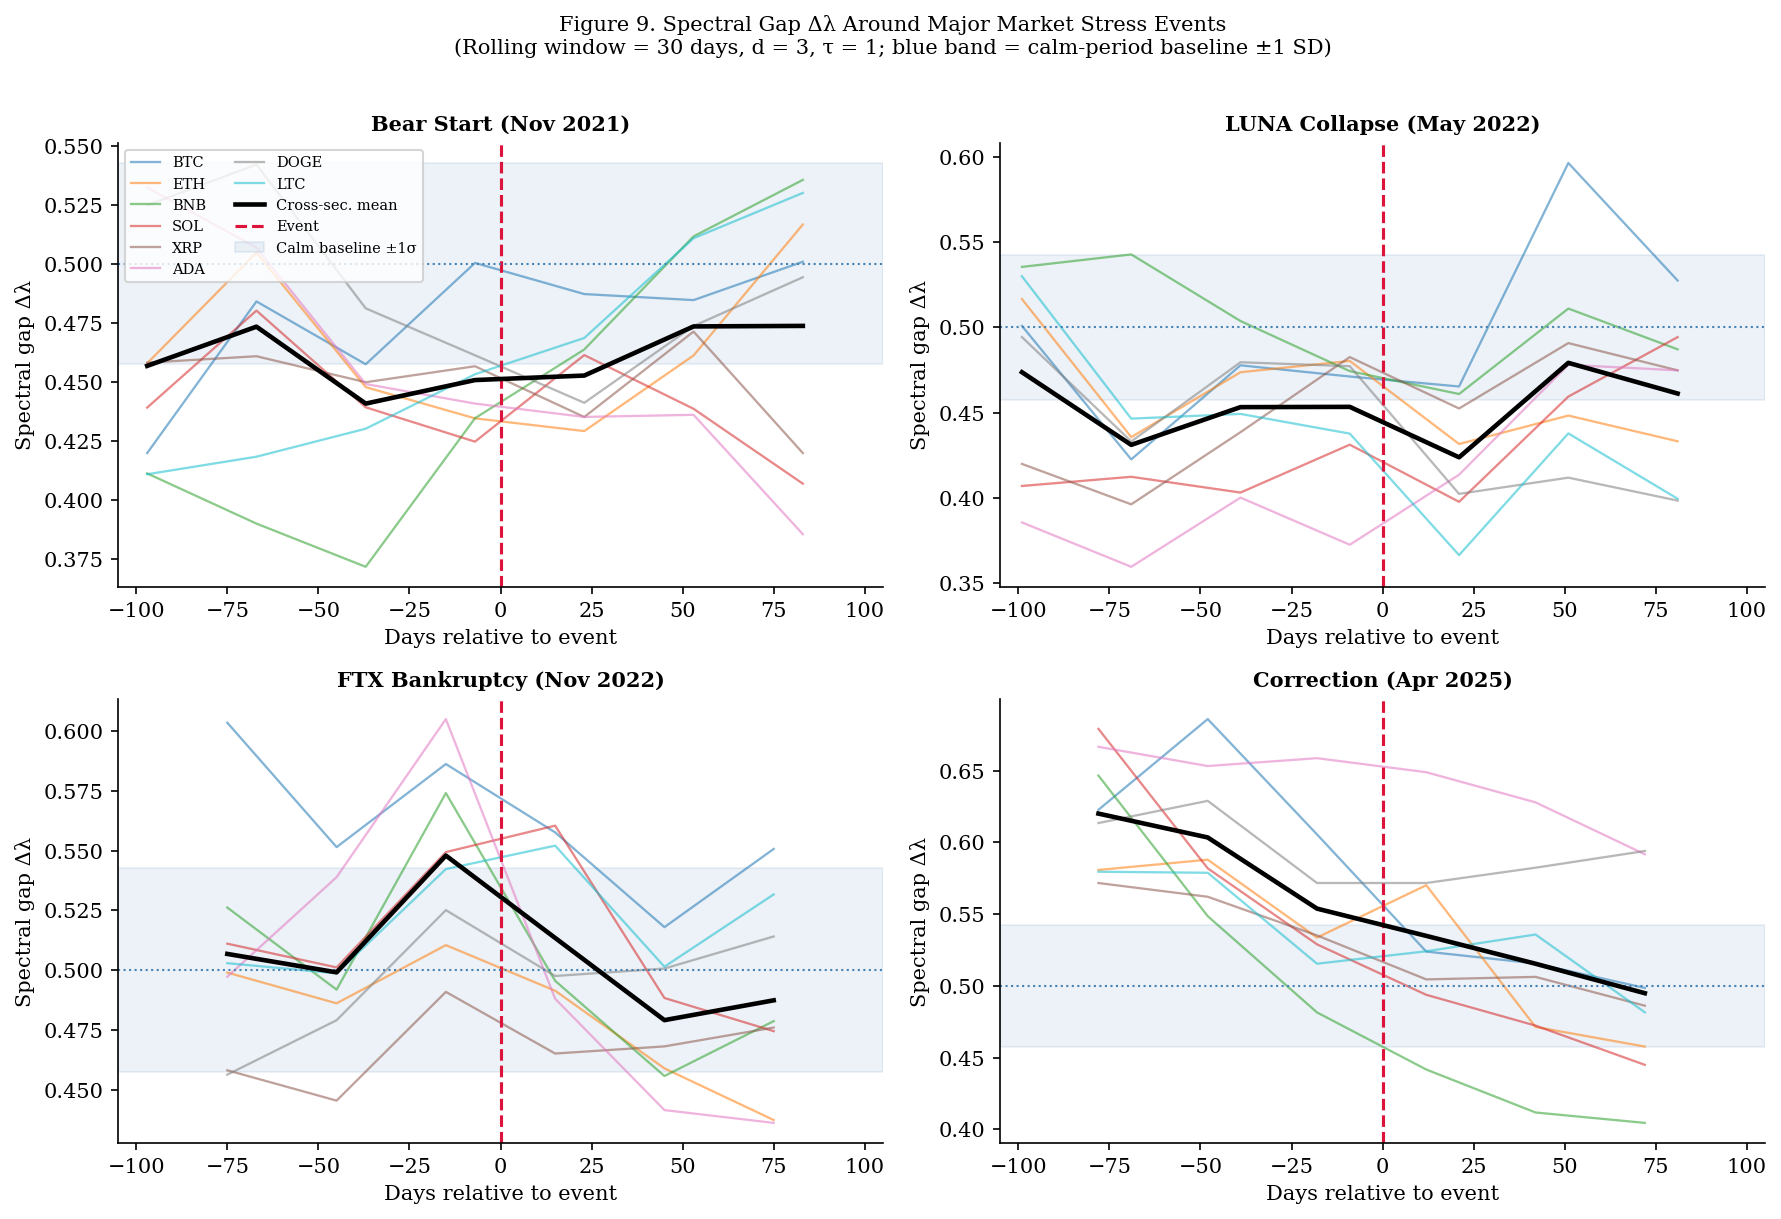

✓ Saved fig_spectral_gap_event_study.png


In [12]:
# ══════════════════════════════════════════════════════════════════
# 10.  FIGURE 9 — 4-panel event study
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=False)
axes = axes.flatten()

for ax_idx, (event_name, event_date) in enumerate(EVENTS.items()):
    ax = axes[ax_idx]
    w  = event_study[event_name]

    # Per-coin lines
    for coin in COINS:
        sub = w[w['coin'] == coin].sort_values('days_to_event')
        ax.plot(sub['days_to_event'], sub['spectral_gap'],
                color=COIN_COLOR[coin], alpha=0.55, linewidth=1.1, label=coin)

    # Cross-sectional mean (bold)
    cs = w.groupby('days_to_event')['spectral_gap'].mean()
    ax.plot(cs.index, cs.values, color='black', linewidth=2.2,
            label='Cross-sec. mean', zorder=5)

    # Event line
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Event')

    # Calm-period baseline band (mean ± 1 SD across 8 coins)
    mu_calm  = baseline['mu'].mean()
    sig_calm = baseline['sigma'].mean()
    ax.axhspan(mu_calm - sig_calm, mu_calm + sig_calm,
               color='steelblue', alpha=0.10, label='Calm baseline ±1σ')
    ax.axhline(mu_calm, color='steelblue', linestyle=':', linewidth=1.0)

    ax.set_title(event_name.replace('\n', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Days relative to event')
    ax.set_ylabel('Spectral gap Δλ')
    ax.set_xlim(-105, 105)
    if ax_idx == 0:
        ax.legend(fontsize=7, ncol=2, loc='upper left')

plt.suptitle('Figure 9. Spectral Gap Δλ Around Major Market Stress Events\n'
             '(Rolling window = 30 days, d = 3, τ = 1; '
             'blue band = calm-period baseline ±1 SD)',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_spectral_gap_event_study.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved fig_spectral_gap_event_study.png')

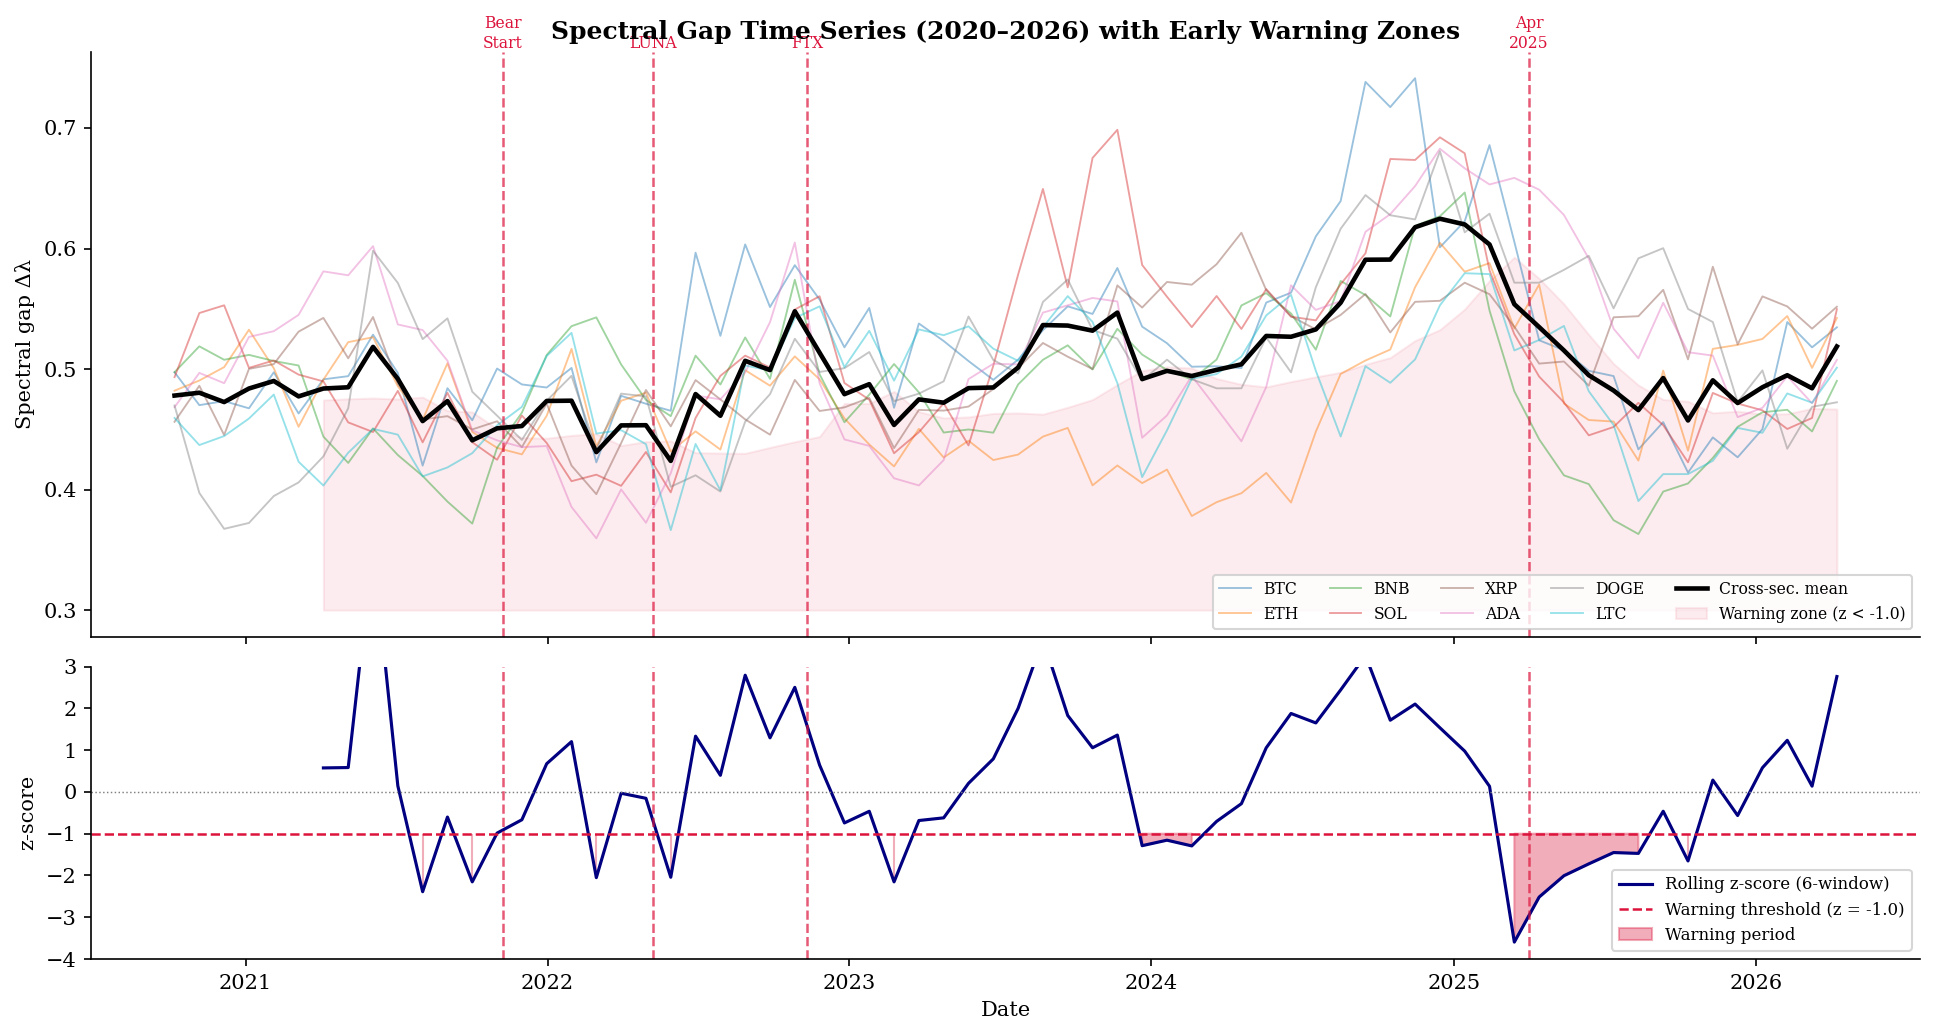

✓ Saved fig_spectral_gap_timeline.png


In [13]:
# ══════════════════════════════════════════════════════════════════
# 11.  FIGURE 10 — full-sample Δλ timeline with events annotated
# ══════════════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# ── Top panel: per-coin + mean ──
for coin in COINS:
    sub = metrics[metrics['coin'] == coin].sort_values('date')
    ax1.plot(sub['date'], sub['spectral_gap'],
             color=COIN_COLOR[coin], alpha=0.45, linewidth=0.9, label=coin)

ax1.plot(xsec['date'], xsec['sg_mean'], color='black', linewidth=2.2,
         label='Cross-sec. mean', zorder=5)

# Warning threshold band
ax1.fill_between(xsec['date'],
                  xsec['sg_roll_mean'] + THRESHOLD * xsec['sg_roll_std'],
                  0.30,
                  where=~xsec['sg_roll_mean'].isna(),
                  alpha=0.08, color='crimson', label=f'Warning zone (z < {THRESHOLD})')

# Event annotations
event_labels_short = {
    'Bear Start\n(Nov 2021)':    ('Bear\nStart', '2021-11-08'),
    'LUNA Collapse\n(May 2022)':  ('LUNA', '2022-05-09'),
    'FTX Bankruptcy\n(Nov 2022)': ('FTX', '2022-11-11'),
    'Correction\n(Apr 2025)':    ('Apr\n2025', '2025-04-02'),
}
for ev_name, (short, date_str) in event_labels_short.items():
    d = pd.Timestamp(date_str, tz='UTC')
    ax1.axvline(d, color='crimson', linestyle='--', linewidth=1.2, alpha=0.7)
    ax1.text(d, ax1.get_ylim()[1] if ax1.get_ylim()[1] > 0.5 else 0.75,
             short, ha='center', fontsize=7.5, color='crimson',
             rotation=0, va='bottom')

ax1.set_ylabel('Spectral gap Δλ')
ax1.set_title('Spectral Gap Time Series (2020–2026) with Early Warning Zones', fontweight='bold')
ax1.legend(fontsize=7.5, ncol=5, loc='lower right')

# ── Bottom panel: rolling z-score ──
xsec_plot = xsec.dropna(subset=['sg_z_roll'])
ax2.plot(xsec_plot['date'], xsec_plot['sg_z_roll'],
         color='navy', linewidth=1.5, label='Rolling z-score (6-window)')
ax2.axhline(THRESHOLD, color='crimson', linestyle='--', linewidth=1.2,
            label=f'Warning threshold (z = {THRESHOLD})')
ax2.fill_between(xsec_plot['date'], xsec_plot['sg_z_roll'], THRESHOLD,
                 where=xsec_plot['sg_z_roll'] < THRESHOLD,
                 alpha=0.35, color='crimson', label='Warning period')
ax2.axhline(0, color='gray', linewidth=0.7, linestyle=':')
for _, d in event_labels_short.items():
    ax2.axvline(pd.Timestamp(d[1], tz='UTC'), color='crimson',
                linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('z-score')
ax2.set_xlabel('Date')
ax2.legend(fontsize=8, loc='lower right')
ax2.set_ylim(-4, 3)

plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_spectral_gap_timeline.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved fig_spectral_gap_timeline.png')

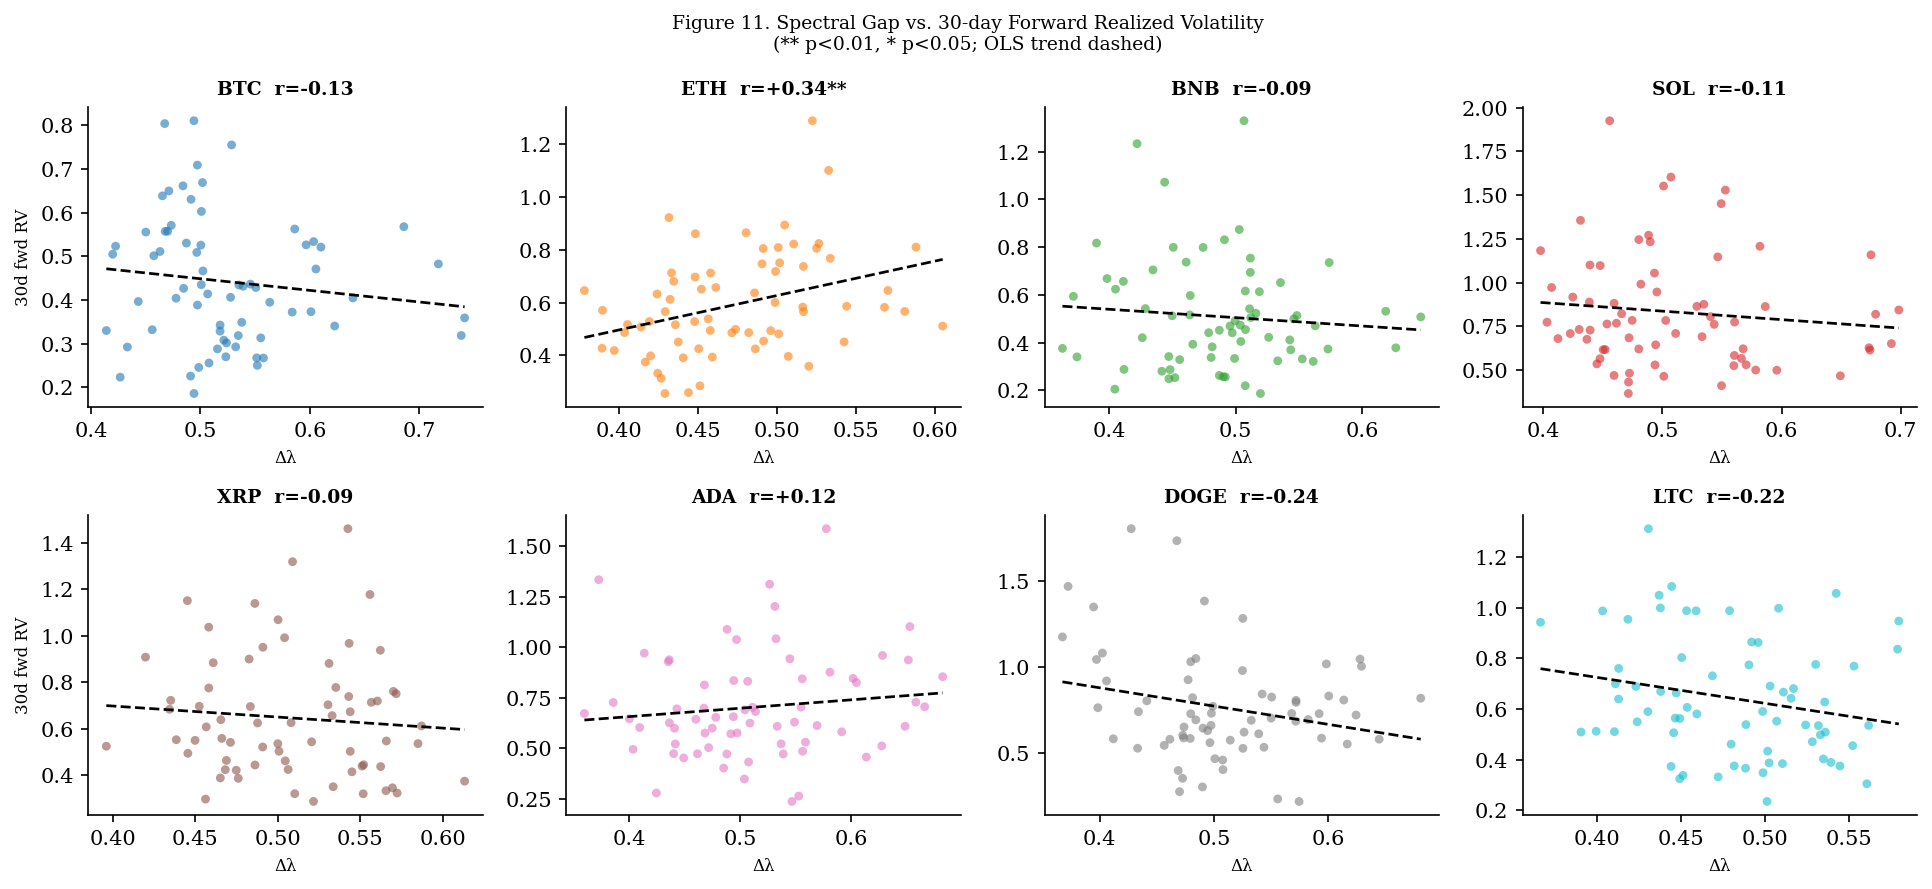

✓ Saved fig_spectral_gap_vs_rv.png


In [14]:
# ══════════════════════════════════════════════════════════════════
# 12.  FIGURE 11 — Scatter: spectral gap vs. forward realized vol
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(13, 6), sharey=False)
axes = axes.flatten()

for i, coin in enumerate(COINS):
    ax = axes[i]
    sub = vol_df[vol_df['coin'] == coin][['spectral_gap', 'rv_forward_30d']].dropna()
    if len(sub) < 5:
        continue
    
    ax.scatter(sub['spectral_gap'], sub['rv_forward_30d'],
               color=COIN_COLOR[coin], alpha=0.6, s=18, edgecolors='none')
    
    # OLS trend line
    m, b, r, p, _ = stats.linregress(sub['spectral_gap'], sub['rv_forward_30d'])
    xs = np.linspace(sub['spectral_gap'].min(), sub['spectral_gap'].max(), 50)
    ax.plot(xs, m * xs + b, color='black', linewidth=1.3, linestyle='--')
    
    sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    ax.set_title(f'{coin}  r={r:+.2f}{sig}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Δλ', fontsize=8)
    if i % 4 == 0:
        ax.set_ylabel('30d fwd RV', fontsize=8)

plt.suptitle('Figure 11. Spectral Gap vs. 30-day Forward Realized Volatility\n'
             '(** p<0.01, * p<0.05; OLS trend dashed)', fontsize=9)
plt.tight_layout()
plt.savefig(DATA_DIR / 'fig_spectral_gap_vs_rv.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('✓ Saved fig_spectral_gap_vs_rv.png')

In [15]:
# ══════════════════════════════════════════════════════════════════
# 13.  TABLE 5 — Manuscript-ready event study table
# ══════════════════════════════════════════════════════════════════

table5_rows = []

for event_name, event_date in EVENTS.items():
    w = event_study[event_name]
    
    far   = w[(w['days_to_event'] >= -90) & (w['days_to_event'] < -30)]
    near  = w[(w['days_to_event'] >= -30) & (w['days_to_event'] < 0)]
    post  = w[(w['days_to_event'] >= 0)   & (w['days_to_event'] <= 60)]

    sg_far  = far['spectral_gap'].mean()  if len(far)  > 0 else np.nan
    sg_near = near['spectral_gap'].mean() if len(near) > 0 else np.nan
    sg_post = post['spectral_gap'].mean() if len(post) > 0 else np.nan
    pct     = (sg_near - sg_far) / sg_far * 100 if not np.isnan(sg_far) else np.nan
    
    z_near = near['sg_z'].mean() if len(near) > 0 else np.nan

    # Mann-Whitney: near_pre vs far_pre (is the distribution significantly lower?)
    if len(far) > 0 and len(near) > 0:
        u, mw_p = stats.mannwhitneyu(
            near['spectral_gap'].values,
            far['spectral_gap'].values,
            alternative='less')
    else:
        mw_p = np.nan

    # Lead-time (from warning analysis)
    prior_w = [d for d in warn_dates if d < event_date]
    lead_days = (event_date - max(prior_w)).days if prior_w else None

    table5_rows.append({
        'Event': event_name.replace('\n', ' '),
        'Δλ (t−90 to t−30)': f'{sg_far:.4f}' if not np.isnan(sg_far) else '—',
        'Δλ (t−30 to t)':    f'{sg_near:.4f}' if not np.isnan(sg_near) else '—',
        'Δλ (t to t+60)':    f'{sg_post:.4f}' if not np.isnan(sg_post) else '—',
        'Pre-event decline':  f'{pct:+.1f}%' if not np.isnan(pct) else '—',
        'z-score (near)':    f'{z_near:+.2f}' if not np.isnan(z_near) else '—',
        'MW p-value':        f'{mw_p:.3f}' if not np.isnan(mw_p) else '—',
        'Lead time (days)':  str(lead_days) if lead_days else 'No prior signal',
    })

table5 = pd.DataFrame(table5_rows)
print('Table 5 (manuscript):')
print(table5.to_string(index=False))

table5.to_csv(DATA_DIR / 'spectral_gap_event_study.csv', index=False)
print('\n✓ Saved spectral_gap_event_study.csv')

Table 5 (manuscript):
                    Event Δλ (t−90 to t−30) Δλ (t−30 to t) Δλ (t to t+60) Pre-event decline z-score (near) MW p-value Lead time (days)
    Bear Start (Nov 2021)            0.4571         0.4508         0.4631             -1.4%          -1.09      0.305               37
 LUNA Collapse (May 2022)            0.4422         0.4534         0.4515             +2.5%          -0.71      0.809               69
FTX Bankruptcy (Nov 2022)            0.5030         0.5479         0.4963             +8.9%          +1.61      0.992              165
    Correction (Apr 2025)            0.6117         0.5538         0.5251             -9.5%          +1.79      0.007               18

✓ Saved spectral_gap_event_study.csv


In [16]:
# ══════════════════════════════════════════════════════════════════
# 14.  TABLE 6 — Granger + correlation results for manuscript
# ══════════════════════════════════════════════════════════════════

print('Table 6: Spectral Gap → Forward Realized Volatility (Granger causality + Pearson r)')
print('─' * 80)

table6_rows = []
for coin in COINS:
    gc_lag1 = granger_df[(granger_df['coin'] == coin) & (granger_df['lag'] == 1)]
    gc_lag2 = granger_df[(granger_df['coin'] == coin) & (granger_df['lag'] == 2)]
    corr_r  = corr_df[corr_df['coin'] == coin]
    
    f1  = gc_lag1['F_stat'].values[0] if len(gc_lag1) > 0 else np.nan
    p1  = gc_lag1['p_value'].values[0] if len(gc_lag1) > 0 else np.nan
    f2  = gc_lag2['F_stat'].values[0] if len(gc_lag2) > 0 else np.nan
    p2  = gc_lag2['p_value'].values[0] if len(gc_lag2) > 0 else np.nan
    r   = corr_r['r_pearson'].values[0] if len(corr_r) > 0 else np.nan
    rp  = corr_r['p_pearson'].values[0] if len(corr_r) > 0 else np.nan
    rs  = corr_r['r_spearman'].values[0] if len(corr_r) > 0 else np.nan
    n   = corr_r['n'].values[0] if len(corr_r) > 0 else 0
    
    def fmt_p(p):
        if np.isnan(p): return '—'
        s = '**' if p < 0.05 else ('†' if p < 0.10 else '')
        return f'{p:.3f}{s}'
    
    table6_rows.append({
        'Coin': coin, 'N': int(n),
        'GC lag=1 F': f'{f1:.2f}' if not np.isnan(f1) else '—',
        'GC lag=1 p': fmt_p(p1),
        'GC lag=2 F': f'{f2:.2f}' if not np.isnan(f2) else '—',
        'GC lag=2 p': fmt_p(p2),
        'Pearson r':  f'{r:+.3f}' if not np.isnan(r) else '—',
        'Pearson p':  fmt_p(rp),
        'Spearman ρ': f'{rs:+.3f}' if not np.isnan(rs) else '—',
    })

table6 = pd.DataFrame(table6_rows)
print(table6.to_string(index=False))

table6.to_csv(DATA_DIR / 'spectral_gap_granger_results.csv', index=False)
print('\n✓ Saved spectral_gap_granger_results.csv')

Table 6: Spectral Gap → Forward Realized Volatility (Granger causality + Pearson r)
────────────────────────────────────────────────────────────────────────────────
Coin  N GC lag=1 F GC lag=1 p GC lag=2 F GC lag=2 p Pearson r Pearson p Spearman ρ
 BTC 68       0.44      0.509       0.13      0.877    -0.129     0.296     -0.185
 ETH 68       1.22      0.273       0.26      0.768    +0.345   0.004**     +0.371
 BNB 68       0.85      0.360       0.75      0.475    -0.090     0.464     -0.042
 SOL 68       0.03      0.869       4.20    0.020**    -0.114     0.357     -0.125
 XRP 68       0.13      0.715       0.48      0.621    -0.087     0.483     -0.132
 ADA 68       0.93      0.338       0.49      0.615    +0.123     0.318     +0.144
DOGE 68       0.57      0.452       0.30      0.742    -0.237    0.052†     -0.117
 LTC 68       0.59      0.445       0.35      0.708    -0.217    0.075†     -0.217

✓ Saved spectral_gap_granger_results.csv


In [17]:
# ══════════════════════════════════════════════════════════════════
# 15.  SUMMARY STATISTICS for manuscript text
# ══════════════════════════════════════════════════════════════════

print('=' * 60)
print('KEY NUMBERS FOR MANUSCRIPT')
print('=' * 60)

# 2025 correction detail
corr_ev = event_study['Correction\n(Apr 2025)']
jan = corr_ev[corr_ev['days_to_event'].between(-90, -60)]['spectral_gap'].mean()
mar = corr_ev[corr_ev['days_to_event'].between(-30, 0)]['spectral_gap'].mean()
post_corr = corr_ev[corr_ev['days_to_event'].between(0, 60)]['spectral_gap'].mean()
print(f'2025 Correction:')
print(f'  Δλ at t-90→-60 (Jan 2025): {jan:.4f}')
print(f'  Δλ at t-30→0  (Mar 2025): {mar:.4f}')
print(f'  Pre-event decline:         {(mar-jan)/jan*100:+.1f}%')
print(f'  Δλ at t+0→+60 (post):     {post_corr:.4f}')

# Per-coin 2025 decline
print('\n  Per-coin Δλ change (t-30→0 vs t-90→-60) for 2025 correction:')
for coin in COINS:
    far_c  = corr_ev[(corr_ev['coin']==coin) & corr_ev['days_to_event'].between(-90,-60)]['spectral_gap'].mean()
    near_c = corr_ev[(corr_ev['coin']==coin) & corr_ev['days_to_event'].between(-30,0)]['spectral_gap'].mean()
    if not np.isnan(far_c) and not np.isnan(near_c):
        print(f'    {coin:5s}: {far_c:.4f} → {near_c:.4f}  ({(near_c-far_c)/far_c*100:+.1f}%)')

# GC significant coins
sig_gc = granger_df[(granger_df['lag']==1) & (granger_df['p_value'] < 0.10)]['coin'].tolist()
print(f'\nGranger causality (lag=1, p<0.10): {sig_gc}')

# Correlation summary
neg_r = corr_df[corr_df['r_pearson'] < 0]
print(f'\nNegative Pearson r (Δλ vs fwd RV): {len(neg_r)}/8 coins')
print(f'Median Pearson r: {corr_df["r_pearson"].median():+.3f}')
print(f'Median Spearman ρ: {corr_df["r_spearman"].median():+.3f}')

# FTX (no warning case)
ftx_ev = event_study['FTX Bankruptcy\n(Nov 2022)']
ftx_near = ftx_ev[ftx_ev['days_to_event'].between(-30,0)]['spectral_gap'].mean()
ftx_far  = ftx_ev[ftx_ev['days_to_event'].between(-90,-30)]['spectral_gap'].mean()
print(f'\nFTX: Δλ change pre-event: {(ftx_near-ftx_far)/ftx_far*100:+.1f}% (no warning expected — idiosyncratic shock)')

KEY NUMBERS FOR MANUSCRIPT
2025 Correction:
  Δλ at t-90→-60 (Jan 2025): 0.6200
  Δλ at t-30→0  (Mar 2025): 0.5538
  Pre-event decline:         -10.7%
  Δλ at t+0→+60 (post):     0.5251

  Per-coin Δλ change (t-30→0 vs t-90→-60) for 2025 correction:
    BTC  : 0.6226 → 0.6055  (-2.8%)
    ETH  : 0.5807 → 0.5336  (-8.1%)
    BNB  : 0.6464 → 0.4815  (-25.5%)
    SOL  : 0.6790 → 0.5289  (-22.1%)
    XRP  : 0.5716 → 0.5351  (-6.4%)
    ADA  : 0.6665 → 0.6586  (-1.2%)
    DOGE : 0.6134 → 0.5716  (-6.8%)
    LTC  : 0.5795 → 0.5154  (-11.1%)

Granger causality (lag=1, p<0.10): []

Negative Pearson r (Δλ vs fwd RV): 6/8 coins
Median Pearson r: -0.102
Median Spearman ρ: -0.121

FTX: Δλ change pre-event: +8.9% (no warning expected — idiosyncratic shock)


In [18]:
print('\n✓ All analyses complete.')
print('Figures saved:')
for f in sorted(DATA_DIR.glob('fig_spectral_gap*.png')):
    print(f'  {f.name}')
print('Tables saved:')
for f in sorted(DATA_DIR.glob('spectral_gap_*.csv')):
    print(f'  {f.name}')


✓ All analyses complete.
Figures saved:
  fig_spectral_gap_event_study.png
  fig_spectral_gap_timeline.png
  fig_spectral_gap_vs_rv.png
Tables saved:
  spectral_gap_event_study.csv
  spectral_gap_granger_results.csv
